In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
import pandas as pd

train = pd.read_csv('dataset\\train.csv')
test = pd.read_csv('dataset\\test.csv')
sample_submission = pd.read_csv('dataset\\sample_submission.csv')


In [3]:
print("Train data shape:", train.shape)
print("Test data shape:", test.shape)
print("\nTrain sample:")
display(train.head())

Train data shape: (20000, 17)
Test data shape: (12000, 16)

Train sample:


,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type,efficiency
0,0,7.817315,576.179270,41.24308670850264,32.135501,4.0,0.803199,37.403527,1.963787,13.691147,62.494044,12.82491203459621,1018.8665053152533,A1,NaN,NaN,0.562096
1,1,24.785727,240.003973,1.3596482765960705,19.977460,8.0,0.479456,21.843315,0.241473,27.545096,43.851238,12.012043660984917,1025.6238537572883,D4,E00,dual-axis,0.396447
2,2,46.652695,687.612799,91.26536837560256,1.496401,4.0,0.822398,48.222882,4.191800,43.363708,NaN,1.814399755560454,1010.9226539809573,C3,E00,NaN,0.573776
3,3,53.339567,735.141179,96.19095521176159,18.491582,3.0,0.837529,46.295748,0.960567,57.720436,67.361473,8.736258932034128,1021.8466633134253,A1,NaN,dual-axis,0.629009
4,4,5.575374,12.241203,27.495073003585226,30.722697,6.0,0.551833,0.000000,0.898062,6.786263,3.632000,0.52268384077164,1008.5559577591927,B2,E00,fixed,0.341874


In [4]:
print("\nMissing values in train data:")
print(train.isnull().sum())


Missing values in train data:
id                       0
temperature           1001
irradiance             987
humidity                 0
panel_age             1011
maintenance_count     1027
soiling_ratio         1010
voltage                993
current                977
module_temperature     978
cloud_coverage        1010
wind_speed               0
pressure                 0
string_id                0
error_code            5912
installation_type     5028
efficiency               0
dtype: int64


In [5]:
display(train.describe())


,id,temperature,irradiance,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,efficiency
count,20000.000000,18999.000000,19013.000000,18989.000000,18973.000000,18990.000000,19007.000000,19023.000000,19022.000000,18990.000000,20000.000000
mean,9999.500000,25.077241,501.273896,17.509758,4.012070,0.698879,16.242251,1.713396,29.923807,51.378575,0.510260
std,5773.647028,12.513129,250.926590,10.097557,2.002268,0.172244,17.889031,1.152953,12.125405,48.473664,0.140420
min,0.000000,0.000000,-597.278646,0.001264,0.000000,0.400149,0.000000,0.000054,0.000000,0.000244,0.000000
25%,4999.750000,16.853522,332.227277,8.777905,3.000000,0.550654,0.000000,0.772311,21.522124,25.081618,0.445613
50%,9999.500000,24.720345,499.654730,17.497731,4.000000,0.697663,12.350138,1.558413,29.857669,49.704133,0.515709
75%,14999.250000,32.848917,668.416734,26.340761,5.000000,0.847838,26.557322,2.474744,38.094943,75.052824,0.590324
max,19999.000000,147.394168,1537.810349,34.998379,15.000000,0.999949,494.279016,7.315597,65.000000,1000.000000,0.987066


## cleaning the train dataset.

In [6]:
num_cols = ['temperature', 'irradiance', 'panel_age', 'maintenance_count', 
            'soiling_ratio', 'voltage', 'current', 'module_temperature', 'cloud_coverage']

for col in num_cols:
    median_value = train[col].median()
    train[col].fillna(median_value, inplace=True)
    test[col].fillna(median_value, inplace=True)

# Step 5: Fill missing categorical columns
train['error_code'].fillna('Missing', inplace=True)
test['error_code'].fillna('Missing', inplace=True)

train['installation_type'].fillna(train['installation_type'].mode()[0], inplace=True)
test['installation_type'].fillna(train['installation_type'].mode()[0], inplace=True)

# Step 6: Encode categorical columns
# For simplicity, using Label Encoding on string_id, error_code, installation_type
cat_cols = ['string_id', 'error_code', 'installation_type']
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    # Fit on train + test combined to avoid unseen labels in test
    le.fit(pd.concat([train[col], test[col]], axis=0))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])
    le_dict[col] = le  # Save encoder if needed later

# Step 7: Confirm no missing values remain
print("\nMissing values after imputation:")
print(train.isnull().sum())

# Step 8: Check head of processed train data
display(train.head())


Missing values after imputation:
id                    0
temperature           0
irradiance            0
humidity              0
panel_age             0
maintenance_count     0
soiling_ratio         0
voltage               0
current               0
module_temperature    0
cloud_coverage        0
wind_speed            0
pressure              0
string_id             0
error_code            0
installation_type     0
efficiency            0
dtype: int64


C:\Users\vidha\AppData\Local\Temp\ipykernel_47008\2118155781.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(median_value, inplace=True)
C:\Users\vidha\AppData\Local\Temp\ipykernel_47008\2118155781.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type,efficiency
0,0,7.817315,576.179270,41.24308670850264,32.135501,4.0,0.803199,37.403527,1.963787,13.691147,62.494044,12.82491203459621,1018.8665053152533,0,3,2,0.562096
1,1,24.785727,240.003973,1.3596482765960705,19.977460,8.0,0.479456,21.843315,0.241473,27.545096,43.851238,12.012043660984917,1025.6238537572883,3,0,0,0.396447
2,2,46.652695,687.612799,91.26536837560256,1.496401,4.0,0.822398,48.222882,4.191800,43.363708,49.704133,1.814399755560454,1010.9226539809573,2,0,2,0.573776
3,3,53.339567,735.141179,96.19095521176159,18.491582,3.0,0.837529,46.295748,0.960567,57.720436,67.361473,8.736258932034128,1021.8466633134253,0,3,0,0.629009
4,4,5.575374,12.241203,27.495073003585226,30.722697,6.0,0.551833,0.000000,0.898062,6.786263,3.632000,0.52268384077164,1008.5559577591927,1,0,1,0.341874


In [ ]:
dis

In [ ]:
test.shape

(12000, 16)

In [9]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(f"Column {col} has non-numeric values")
        print(X_train[col].unique())

NameError: name 'X_train' is not defined

In [11]:
for col in ['humidity', 'wind_speed', 'pressure']:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

In [12]:
for col in ['humidity', 'wind_speed', 'pressure']:
    median_value = train[col].median()
    train[col].fillna(median_value, inplace=True)
    test[col].fillna(median_value, inplace=True)


C:\Users\vidha\AppData\Local\Temp\ipykernel_47008\2582502085.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(median_value, inplace=True)
C:\Users\vidha\AppData\Local\Temp\ipykernel_47008\2582502085.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [13]:
train[col].dtype


dtype('float64')

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepare features and target
X = train.drop(['id', 'efficiency'], axis=1)
y = train['efficiency']

# Split train data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on validation set
y_pred = lr_model.predict(X_val)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Linear Regression Validation RMSE: {rmse:.4f}')

# Custom Score = 100 * (1 - RMSE)
score = 100 * (1 - rmse)
print(f'Custom Score: {score:.2f}')


Linear Regression Validation RMSE: 0.1081
Custom Score: 89.19


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Step 1: Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=300,        # number of trees
    max_depth=None,          # allow trees to expand fully
    random_state=42,         # for reproducibility
    n_jobs=-1                # use all CPU cores
)

# Step 2: Train the model
rf_model.fit(X_train, y_train)

# Step 3: Predict on validation set
y_pred_rf = rf_model.predict(X_val)

# Step 4: Evaluate the model
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
custom_score = 100 * (1 - rmse)

print(f"Random Forest Validation RMSE: {rmse:.4f}")
print(f"Custom Score: {custom_score:.2f}")


Random Forest Validation RMSE: 0.1092
Custom Score: 89.08


In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

# Evaluate tuned model
y_pred_best = best_rf.predict(X_val)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
score_best = 100 * (1 - rmse_best)

print(f"Tuned RF RMSE: {rmse_best:.4f}")
print(f"Tuned RF Score: {score_best:.2f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuned RF RMSE: 0.1080
Tuned RF Score: 89.20


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define parameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Grid search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Save the best model
rf_best = grid_search.best_estimator_


Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [20]:
importances = rf_best.feature_importances_
feature_names = X_train.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Feature Importance - Tuned Random Forest')
plt.tight_layout()
plt.show()


NameError: name 'rf_best' is not defined

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming your train data is ready and cleaned
X = train.drop(columns=['id', 'efficiency'])
y = train['efficiency']

# Train-validation split (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # for regression
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on validation set
y_pred = xgb_model.predict(X_val)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"XGBoost Validation RMSE: {rmse:.4f}")

# Calculate custom score
custom_score = 100 * (1 - rmse)
print(f"XGBoost Custom Score: {custom_score:.2f}")


XGBoost Validation RMSE: 0.1076
XGBoost Custom Score: 89.24


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import numpy as np

# Prepare data (if not already done)
X = train.drop(columns=['id', 'efficiency'])
y = train['efficiency']

# Split again just in case
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBRegressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define parameter grid for RandomizedSearch
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,            # number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit random search
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")

# Evaluate on validation
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Tuned XGBoost Validation RMSE: {rmse:.4f}")
print(f"Tuned XGBoost Custom Score: {100*(1-rmse):.2f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 0.6, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Tuned XGBoost Validation RMSE: 0.1063
Tuned XGBoost Custom Score: 89.37


In [ ]:
!pip install xgboost

     -------------------------------------- 150.0/150.0 MB 2.5 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error


lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'early_stopping_rounds': 50,
    "verbose_eval":False
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
   
    
)


y_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
mse = mean_squared_error(y_val, y_pred_lgb)  # by default returns MSE
rmse = mse ** 0.5  # take square root for RMSE
print("RMSE:", rmse)

score = 100 * (1 - rmse)
print("Custom Score:", score)

print(f"LightGBM Validation RMSE: {rmse:.4f}")
print(f"LightGBM Custom Score: {score:.2f}")


RMSE: 0.10662765507132134
Custom Score: 89.33723449286786
LightGBM Validation RMSE: 0.1066
LightGBM Custom Score: 89.34


In [ ]:
from catboost import CatBoostRegressor

cat_features = [X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]

cat_model = CatBoostRegressor(random_seed=42, silent=True)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_features, early_stopping_rounds=50)

y_pred_cat = cat_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred_lgb)  # by default returns MSE
rmse = mse ** 0.5  # take square root for RMSE
print("RMSE:", rmse)
score = 100 * (1 - rmse)

print(f"CatBoost Validation RMSE: {rmse:.4f}")
print(f"CatBoost Custom Score: {score:.2f}")


RMSE: 0.10662765507132134
CatBoost Validation RMSE: 0.1066
CatBoost Custom Score: 89.34


In [ ]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred_svr)  # by default returns MSE
rmse = mse ** 0.5  # take square root for RMSE
print("RMSE:", rmse)
score = 100 * (1 - rmse)

print(f"SVR Validation RMSE: {rmse:.4f}")
print(f"SVR Custom Score: {score:.2f}")


RMSE: 0.11558633282728956
SVR Validation RMSE: 0.1156
SVR Custom Score: 88.44


In [ ]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(random_state=42)
elastic_model.fit(X_train, y_train)

y_pred_elastic = elastic_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred_elastic)  # by default returns MSE
rmse = mse ** 0.5  # take square root for RMSE
print("RMSE:", rmse)
score = 100 * (1 - rmse)


print(f"ElasticNet Validation RMSE: {rmse:.4f}")
print(f"ElasticNet Custom Score: {score:.2f}")


RMSE: 0.11854730215927725
ElasticNet Validation RMSE: 0.1185
ElasticNet Custom Score: 88.15


In [ ]:
# Feature Engineering
train_fe = train.copy()
test_fe = test.copy()

# 1. Interaction terms
train_fe['power'] = train_fe['voltage'] * train_fe['current']
test_fe['power'] = test_fe['voltage'] * test_fe['current']

train_fe['irr_temp'] = train_fe['irradiance'] * train_fe['temperature']
test_fe['irr_temp'] = test_fe['irradiance'] * test_fe['temperature']

train_fe['hum_wind'] = train_fe['humidity'].astype(float) * train_fe['wind_speed'].astype(float)
test_fe['hum_wind'] = test_fe['humidity'].astype(float) * test_fe['wind_speed'].astype(float)

# 2. Log transformation
train_fe['log_pressure'] = np.log(train_fe['pressure'].astype(float))
test_fe['log_pressure'] = np.log(test_fe['pressure'].astype(float))

# Drop old columns if redundant (optional)
# train_fe.drop(columns=['pressure'], inplace=True)
# test_fe.drop(columns=['pressure'], inplace=True)


In [63]:
# Use same features as X and y
from xgboost import XGBRegressor
X = train_fe.drop(columns=['efficiency'])  # Replace 'target' with your label column
y = train_fe['efficiency']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Reuse best parameters from earlier
xgb_model = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=150,
    subsample=0.6,
    colsample_bytree=1.0,
    gamma=0,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)  # by default returns MSE
rmse = mse ** 0.5  # take square root for RMSE
print("RMSE:", rmse)
score = 100 * (1 - rmse)
print(f"🚀 New XGBoost RMSE: {rmse:.4f}")
print(f"🚀 New Custom Score: {score:.2f}")


RMSE: 0.10649253291851125
🚀 New XGBoost RMSE: 0.1065
🚀 New Custom Score: 89.35


In [67]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_best = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.6,
    colsample_bytree=1.0,
    gamma=0,
    random_state=42
)

xgb_best.fit(X_train, y_train)
xgb_preds = xgb_best.predict(X_val)

mse_xgb = mean_squared_error(y_val, xgb_preds)
rmse_xgb = np.sqrt(mse_xgb)
custom_score_xgb = (1 - rmse_xgb) * 100

print(f"✅ Tuned XGBoost RMSE: {rmse_xgb:.4f}")
print(f"✅ Tuned XGBoost Custom Score: {custom_score_xgb:.2f}")


✅ Tuned XGBoost RMSE: 0.1065
✅ Tuned XGBoost Custom Score: 89.35


In [71]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 42,
    'early_stopping_rounds':50, 
    'verbose_eval':False

}

lgb_model = lgb.train(params, lgb_train, valid_sets=[lgb_val])

y_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
mse_lgb = mean_squared_error(y_val, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
custom_score_lgb = (1 - rmse_lgb) * 100

print(f"✅ LightGBM RMSE: {rmse_lgb:.4f}")
print(f"✅ LightGBM Custom Score: {custom_score_lgb:.2f}")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[46]	valid_0's rmse: 0.106303
✅ LightGBM RMSE: 0.1063
✅ LightGBM Custom Score: 89.37


In [35]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

cat_model = CatBoostRegressor(
    iterations=150,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=False
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

y_pred_cat = cat_model.predict(X_val)
mse_cat = mean_squared_error(y_val, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
custom_score_cat = (1 - rmse_cat) * 100

print(f"✅ CatBoost RMSE: {rmse_cat:.4f}")
print(f"✅ CatBoost Custom Score: {custom_score_cat:.2f}")


✅ CatBoost RMSE: 0.1061
✅ CatBoost Custom Score: 89.39


## Here I am adding code to generate the test file efficiency and then converting it into submitio  csv

In [20]:
test

,id,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type
0,0,17.618379,85.449838,90.815423,13.910963,6.0,0.889765,6.370396,0.069101,19.517274,33.509889,7.181958,1034.782455,2,1,2
1,1,34.826323,722.801748,20.982993,20.916528,4.0,0.590372,30.095867,1.713852,37.421443,32.327060,4.184582,992.319752,3,0,2
2,2,33.776934,485.491998,55.614050,1.446962,3.0,0.611425,28.424430,1.696936,32.147763,69.613333,6.259441,999.213457,3,1,0
3,3,18.584189,350.022720,49.044766,18.810133,5.0,0.697663,7.848038,0.787188,25.734118,42.862760,2.769607,1026.650078,2,2,0
4,4,43.044908,437.295622,8.761571,17.497731,8.0,0.564938,12.300717,1.867620,29.857669,51.025763,11.846974,1010.809943,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,11995,40.581656,492.446562,35.496012,4.508170,8.0,0.697663,40.883724,3.434505,48.476050,14.015174,3.135128,1008.966267,3,0,2
11996,11996,16.958524,198.844667,4.063816,4.021203,4.0,0.810999,0.000000,1.290352,23.502657,22.788465,9.363424,1023.566458,2,2,2
11997,11997,24.055333,757.621634,2.797670,15.253932,3.0,0.697663,5.855590,4.835729,31.908375,98.197373,14.355945,1011.665828,0,0,2
11998,11998,15.623725,177.376256,0.671049,16.437613,2.0,0.861087,0.000000,1.159060,23.835495,9.581184,6.958665,1017.657263,1,3,0


In [21]:
X_test_final = test.drop(columns=['id'])
X_test_final

,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type
0,17.618379,85.449838,90.815423,13.910963,6.0,0.889765,6.370396,0.069101,19.517274,33.509889,7.181958,1034.782455,2,1,2
1,34.826323,722.801748,20.982993,20.916528,4.0,0.590372,30.095867,1.713852,37.421443,32.327060,4.184582,992.319752,3,0,2
2,33.776934,485.491998,55.614050,1.446962,3.0,0.611425,28.424430,1.696936,32.147763,69.613333,6.259441,999.213457,3,1,0
3,18.584189,350.022720,49.044766,18.810133,5.0,0.697663,7.848038,0.787188,25.734118,42.862760,2.769607,1026.650078,2,2,0
4,43.044908,437.295622,8.761571,17.497731,8.0,0.564938,12.300717,1.867620,29.857669,51.025763,11.846974,1010.809943,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,40.581656,492.446562,35.496012,4.508170,8.0,0.697663,40.883724,3.434505,48.476050,14.015174,3.135128,1008.966267,3,0,2
11996,16.958524,198.844667,4.063816,4.021203,4.0,0.810999,0.000000,1.290352,23.502657,22.788465,9.363424,1023.566458,2,2,2
11997,24.055333,757.621634,2.797670,15.253932,3.0,0.697663,5.855590,4.835729,31.908375,98.197373,14.355945,1011.665828,0,0,2
11998,15.623725,177.376256,0.671049,16.437613,2.0,0.861087,0.000000,1.159060,23.835495,9.581184,6.958665,1017.657263,1,3,0


In [26]:
# Step 1: Predict on test data
y_test_pred = cat_model.predict(X_test_final)

# Step 2: Create submission DataFrame
submission = pd.DataFrame({
    'id': test['id'],              # Ensure test has the same id column
    'efficiency': y_test_pred
})

# Step 3: Save to CSV in correct format
submission.to_csv('final_submission.csv', index=False)

print("🎯 Submission file 'final_submission.csv' created successfully.")


🎯 Submission file 'final_submission.csv' created successfully.


In [27]:
submission.shape

(12000, 2)

In [37]:
# Feature Engineering on Train
train['power_output'] = train['voltage'] * train['current']
train['temp_diff'] = train['module_temperature'] - train['temperature']
train['irradiance_per_cloud'] = train['irradiance'] / (train['cloud_coverage'] + 1)

# Do the same for test dataset
test['power_output'] = test['voltage'] * test['current']
test['temp_diff'] = test['module_temperature'] - test['temperature']
test['irradiance_per_cloud'] = test['irradiance'] / (test['cloud_coverage'] + 1)


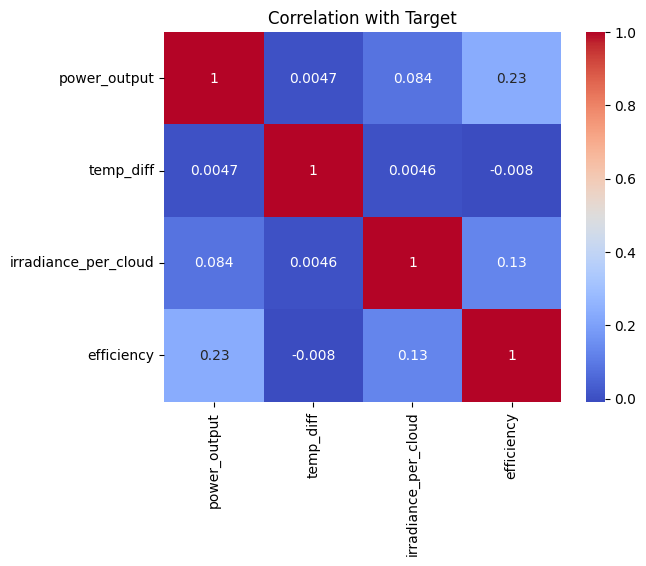

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
features_to_check = ['power_output', 'temp_diff', 'irradiance_per_cloud', 'efficiency']
sns.heatmap(train[features_to_check].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation with Target")
plt.show()


In [73]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Base models
catboost_model = CatBoostRegressor(iterations=1000, early_stopping_rounds=50, verbose=False, random_state=42)
lightgbm_model = lgb.LGBMRegressor(n_estimators=1000, random_state=42)
xgboost_model = XGBRegressor(n_estimators=150, max_depth=3, learning_rate=0.1, subsample=0.6, random_state=42)

# Final estimator for stacking
final_estimator = LinearRegression()


In [36]:
stacking_regressor = StackingRegressor(
    estimators=[
        ('catboost', catboost_model),
        ('lightgbm', lightgbm_model),
        ('xgboost', xgboost_model)
    ],
    final_estimator=final_estimator,
    cv=3,
    n_jobs=-1
)

# Train stacking regressor
stacking_regressor.fit(X_train, y_train)


NameError: name 'StackingRegressor' is not defined

In [76]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_val, y_pred_stack)
rmse_stack = np.sqrt(mse)

custom_score_stack = 100 * (1 - rmse_stack)

print(f"Stacking Regressor Validation RMSE: {rmse_stack:.4f}")
print(f"Stacking Regressor Custom Score: {custom_score_stack:.2f}")


Stacking Regressor Validation RMSE: 0.1064
Stacking Regressor Custom Score: 89.36


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=30, verbose=False)

y_pred_lgb = lgb_model.predict(X_val)
rmse_lgb = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
score_lgb = (1 - rmse_lgb) * 100

print(f"🌟 LightGBM RMSE: {rmse_lgb:.4f}")
print(f"🌟 LightGBM Custom Score: {score_lgb:.2f}")


TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'verbose'